<a href="https://colab.research.google.com/github/AmirMohammad73/semantic_folding/blob/main/SOM_fingerprint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install Minisom
!pip install Levenshtein
!pip install scipy

  Preparing metadata (setup.py) ... done
  Created wheel for Minisom: filename=MiniSom-2.3.2-py3-none-any.whl size=10650 sha256=a79706d49ccb1a6a49b6d9950cf39de5b2bc800aafba14aa6153120f07e799a6
  Stored in directory: /root/.cache/pip/wheels/b4/f6/8a/9daf8831901c3e3805775633404248f10663d1c80b7e5a1314
Successfully built Minisom
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.4/177.4 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 11.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from minisom import MiniSom
import os
import gensim.downloader as api

# Load corpus
with open("/content/drive/MyDrive/secondopenbook1.txt", "r") as file:
    corpus = file.readlines()

# Load GloVe word embeddings
glove_model = api.load("glove-wiki-gigaword-300")

# Set a seed for reproducibility
np.random.seed(123)
DIMENSION = 25

# Create document vectors using GloVe embeddings
document_vectors = []
for doc in corpus:
    doc_vector = []
    for word in doc.split():
        if word in glove_model:
            doc_vector.append(glove_model[word])
    if doc_vector:
        document_vectors.append(np.mean(doc_vector, axis=0))
    else:
        document_vectors.append(np.zeros(300))

# Dimensionality reduction
n_components = 300
svd = TruncatedSVD(n_components=n_components)
document_vectors_reduced = svd.fit_transform(document_vectors)

# Document Clustering with SOM
som_x, som_y = 25, 25  # Adjust SOM grid dimensions to match DIMENSION
som = MiniSom(som_x, som_y, n_components, sigma=0.5, learning_rate=0.5)
som.pca_weights_init(document_vectors_reduced)
som.train_random(document_vectors_reduced, 1000)

# Get the position of the best matching units (BMUs) for each document vector
bmu_matrix = np.array([som.winner(d) for d in document_vectors]).T

# Step 1: Get the range for the BMU matrix
x_min, x_max = bmu_matrix[0].min(), bmu_matrix[0].max()
y_min, y_max = bmu_matrix[1].min(), bmu_matrix[1].max()

# Step 2: Create a 16x16 grid to bin the data
num_bins = DIMENSION
x_edges = np.linspace(x_min, x_max, num_bins + 1)
y_edges = np.linspace(y_min, y_max, num_bins + 1)

# Step 3: Adjusted calculation of bin indices to ensure they fall within 0-15
x_bin_indices = np.clip(np.digitize(bmu_matrix[0], bins=x_edges[:-1]) - 1, 0, DIMENSION - 1)
y_bin_indices = np.clip(np.digitize(bmu_matrix[1], bins=y_edges[:-1]) - 1, 0, DIMENSION - 1)

# Now, all bin indices should be within the range [0, DIMENSION - 1], which means 0 to 15

# Step 4: Make a list of 16x16 grid coordinates plus document IDs
mapped_data = list(zip(x_bin_indices, y_bin_indices, range(len(document_vectors))))

# Convert to a numpy array if necessary
mapped_data_array = np.array(mapped_data)

# Initialize a fourth column in 'mapped_data_array' for the frequency counts, setting them initially to zero
mapped_data_array = np.hstack((mapped_data_array, np.zeros((mapped_data_array.shape[0], 1), dtype=int)))


/usr/local/lib/python3.10/dist-packages/minisom.py:388: ComplexWarning: Casting complex values to real discards the imaginary part
  self._weights[i, j] = c1*pc[pc_order[0]] + \


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from minisom import MiniSom
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Set a seed for reproducibility
np.random.seed(123)
DIMENSION = 16

# Load corpus
with open("/content/drive/MyDrive/cleaned_corpus_final1.txt", "r") as file:
    corpus = file.readlines()

# TF-IDF vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5988)
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

# Dimensionality reduction
n_components = 5988
svd = TruncatedSVD(n_components=n_components)
document_vectors = svd.fit_transform(tfidf_matrix)


In [2]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
from nltk.corpus import wordnet
import spacy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from minisom import MiniSom
import json

# Load spaCy's English model
nlp = spacy.load("en_core_web_sm")

def standardize_synonyms(text):
    words = text.split()
    standardized_words = []
    for word in words:
        synsets = wordnet.synsets(word)
        if synsets:
            standardized_word = synsets[0].lemmas()[0].name()
            standardized_words.append(standardized_word)
        else:
            standardized_words.append(word)
    return " ".join(standardized_words)

# Load corpus
with open("/content/drive/MyDrive/cleaned_devclean.txt", "r") as file:
    corpus = file.readlines()

# Standardize synonyms in the corpus using spaCy lemmatization
standardized_corpus = [standardize_synonyms(context) for context in corpus]

# Create a TF-IDF vectorizer
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(standardized_corpus)

# Get the vocabulary and its indices
vocabulary = vectorizer.get_feature_names_out()

# Initialize the document vectors
num_contexts = len(standardized_corpus)
num_vocab = len(vocabulary)
document_vectors = np.zeros((num_contexts, num_vocab))

# Fill in the document vectors with TF-IDF values
for i, context in enumerate(standardized_corpus):
    context_tfidf = tfidf_matrix[i].toarray().flatten()
    document_vectors[i] = context_tfidf



In [4]:
# Clustering with SOM
som_model = MiniSom(20, 20, document_vectors.shape[1], sigma=1.0, learning_rate=0.5)  # Define SOM parameters
som_model.random_weights_init(document_vectors)  # Initialize SOM nodes with PCA
som_model.train_random(document_vectors, 10000)  # Train SOM with 10,000 iterations

# Get the winning nodes for each document vector
winning_nodes = np.array([som_model.winner(x) for x in document_vectors])
# Step 1: Get the range for the winning nodes
x_min, x_max = winning_nodes[:, 0].min(), winning_nodes[:, 0].max()
y_min, y_max = winning_nodes[:, 1].min(), winning_nodes[:, 1].max()

# Step 2: Create a 16x16 grid to bin the data
num_bins = 20
x_edges = np.linspace(x_min, x_max, num_bins)
y_edges = np.linspace(y_min, y_max, num_bins)

# Step 3: Assign document ID to the respective bins (the result will be indices of the bins)
x_bin_indices = np.digitize(winning_nodes[:, 0], bins=x_edges) - 1  # -1 to convert to 0-indexed
y_bin_indices = np.digitize(winning_nodes[:, 1], bins=y_edges) - 1  # -1 to convert to 0-indexed

# Step 4: Make a list of 16x16 grid coordinates plus document IDs
mapped_data = list(zip(x_bin_indices, y_bin_indices, range(len(document_vectors))))

# Convert to a numpy array if necessary
mapped_data_array = np.array(mapped_data)

# Initialize a fourth column in 'mapped_data_array' for the frequency counts, setting them initially to zero
mapped_data_array = np.hstack((mapped_data_array, np.zeros((mapped_data_array.shape[0], 1), dtype=int)))

In [5]:
import math
# Define a function to calculate the Euclidean distance between two matrices
def calculate_euclidean_distance(matrix1, matrix2):
    # Ensure that both matrices have the same shape
    if matrix1.shape != matrix2.shape:
        raise ValueError("Matrices must have the same dimensions to calculate Euclidean distance.")

    # Flatten the matrices to 1D arrays
    matrix1_flat = matrix1.flatten()
    matrix2_flat = matrix2.flatten()

    # Calculate the Euclidean distance
    euclidean_distance = math.dist(matrix1_flat, matrix2_flat)
    return euclidean_distance

# Assuming 'matrices' is a list of 5 matrices where the first matrix is the question
# and the next four are the options
def compare_question_to_options_euclidean(matrices):
    question_matrix = matrices[0]
    options_matrices = matrices[1:]
    euclidean_distances = []

    # Calculate the Euclidean distance of the question to each option
    for option_matrix in options_matrices:
        distance = calculate_euclidean_distance(question_matrix, option_matrix)
        euclidean_distances.append(distance)

    # Since we want similarity, not distance, we can invert the distances
    # The smaller the distance, the higher the similarity
    euclidean_similarities = [1 / distance if distance != 0 else float('inf') for distance in euclidean_distances]

    return euclidean_similarities


In [6]:
from scipy.spatial import distance
# Define a function to calculate the Hamming distance between two matrices
def calculate_hamming_distance(matrix1, matrix2):
    # Ensure that both matrices have the same shape
    if matrix1.shape != matrix2.shape:
        raise ValueError("Matrices must have the same dimensions to calculate Hamming distance.")

    # Flatten the matrices to 1D arrays
    matrix1_flat = matrix1.flatten()
    matrix2_flat = matrix2.flatten()

    # Calculate the Hamming distance
    hamming_distance = distance.hamming(matrix1_flat, matrix2_flat)
    return hamming_distance

# Define a function to calculate the similarity based on Hamming distance
def calculate_hamming_similarity(matrix1, matrix2):
    hamming_distance = calculate_hamming_distance(matrix1, matrix2)
    hamming_similarity = 1 - (hamming_distance)
    return hamming_similarity

# Assuming 'matrices' is a list of 5 matrices where the first matrix is the question
# and the next four are the options
def compare_question_to_options_hamming(matrices):
    question_matrix = matrices[0]
    options_matrices = matrices[1:]
    hamming_similarities = []

    # Calculate the Hamming similarity of the question to each option
    for option_matrix in options_matrices:
        similarity = calculate_hamming_similarity(question_matrix, option_matrix)
        hamming_similarities.append(similarity)

    return hamming_similarities

In [7]:
# Define a function to calculate the Jaccard similarity between two matrices
def calculate_jaccard_similarity(matrix1, matrix2):
    # Ensure that both matrices have the same shape
    if matrix1.shape != matrix2.shape:
        raise ValueError("Matrices must have the same dimensions to calculate Jaccard similarity.")

    # Flatten the matrices to 1D arrays
    matrix1_flat = matrix1.flatten()
    matrix2_flat = matrix2.flatten()

    # Calculate the intersection and union of the matrices
    intersection = np.sum(np.minimum(matrix1_flat, matrix2_flat))
    union = np.sum(np.maximum(matrix1_flat, matrix2_flat))

    # Calculate the Jaccard similarity
    jaccard_similarity = intersection / union if union != 0 else 0
    return jaccard_similarity

# Assuming 'matrices' is a list of 5 matrices where the first matrix is the question
# and the next four are the options
def compare_question_to_options_jaccard(matrices):
    question_matrix = matrices[0]
    options_matrices = matrices[1:]
    jaccard_similarities = []

    # Calculate the Jaccard similarity of the question to each option
    for option_matrix in options_matrices:
        similarity = calculate_jaccard_similarity(question_matrix, option_matrix)
        jaccard_similarities.append(similarity)

    return jaccard_similarities


In [8]:
from numpy.linalg import norm
# Define a function to calculate the Cosine similarity between two matrices
def calculate_cosine_similarity(matrix1, matrix2):
    # Ensure that both matrices have the same shape
    if matrix1.shape != matrix2.shape:
        raise ValueError("Matrices must have the same dimensions to calculate Cosine similarity.")

    # Flatten the matrices to 1D arrays
    matrix1_flat = matrix1.flatten()
    matrix2_flat = matrix2.flatten()

    # Calculate the dot product and magnitudes of the matrices
    dot_product = np.dot(matrix1_flat, matrix2_flat)
    magnitude1 = norm(matrix1_flat)
    magnitude2 = norm(matrix2_flat)

    # Calculate the Cosine similarity
    cosine_similarity = dot_product / (magnitude1 * magnitude2) if magnitude1 != 0 and magnitude2 != 0 else 0
    return cosine_similarity

# Assuming 'matrices' is a list of 5 matrices where the first matrix is the question
# and the next four are the options
def compare_question_to_options_cosine(matrices):
    question_matrix = matrices[0]
    options_matrices = matrices[1:]
    cosine_similarities = []

    # Calculate the Cosine similarity of the question to each option
    for option_matrix in options_matrices:
        similarity = calculate_cosine_similarity(question_matrix, option_matrix)
        cosine_similarities.append(similarity)

    return cosine_similarities

In [9]:
from Levenshtein import distance as levenshtein_distance

# Define a function to calculate the Levenshtein distance between two matrices
def calculate_levenshtein_distance(matrix1, matrix2):
    # Ensure that both matrices have the same shape
    if matrix1.shape != matrix2.shape:
        raise ValueError("Matrices must have the same dimensions to calculate Levenshtein distance.")

    # Flatten the matrices to 1D arrays
    matrix1_flat = matrix1.flatten()
    matrix2_flat = matrix2.flatten()

    # Convert the arrays to strings
    matrix1_str = ''.join(map(str, matrix1_flat))
    matrix2_str = ''.join(map(str, matrix2_flat))

    # Calculate the Levenshtein distance
    levenshtein_distance_value = levenshtein_distance(matrix1_str, matrix2_str)

    return levenshtein_distance_value

# Define a function to calculate the similarity based on Levenshtein distance
def calculate_levenshtein_similarity(matrix1, matrix2):
    levenshtein_distance_value = calculate_levenshtein_distance(matrix1, matrix2)
    max_distance = max(matrix1.size, matrix2.size)
    levenshtein_similarity = 1 - (levenshtein_distance_value / max_distance)
    return levenshtein_similarity

# Assuming 'matrices' is a list of 5 matrices where the first matrix is the question
# and the next four are the options
def compare_question_to_options_levenshtein(matrices):
    question_matrix = matrices[0]
    options_matrices = matrices[1:]
    levenshtein_similarities = []

    # Calculate the Levenshtein similarity of the question to each option
    for option_matrix in options_matrices:
        similarity = calculate_levenshtein_similarity(question_matrix, option_matrix)
        levenshtein_similarities.append(similarity)

    return levenshtein_similarities

In [10]:
def calculate_sorensen_dice_index(matrix1, matrix2):
    # Ensure that both matrices have the same shape
    if matrix1.shape != matrix2.shape:
        raise ValueError("Matrices must have the same dimensions to calculate Sørensen-Dice index.")

    # Flatten the matrices to 1D arrays
    matrix1_flat = matrix1.flatten()
    matrix2_flat = matrix2.flatten()

    # Calculate the Sørensen-Dice index
    intersection = np.sum(np.minimum(matrix1_flat, matrix2_flat)) * 2
    total = np.sum(matrix1_flat) + np.sum(matrix2_flat)
    sorensen_dice_index = intersection / total if total != 0 else 0
    return sorensen_dice_index

# Assuming 'matrices' is a list of 5 matrices where the first matrix is the question
# and the next four are the options
def compare_question_to_options_sorensen_dice(matrices):
    question_matrix = matrices[0]
    options_matrices = matrices[1:]
    sorensen_dice_indices = []

    # Calculate the Sørensen-Dice index of the question to each option
    for option_matrix in options_matrices:
        index = calculate_sorensen_dice_index(question_matrix, option_matrix)
        sorensen_dice_indices.append(index)

    return sorensen_dice_indices

In [11]:
def matrix_to_sdr(matrix, num_largest):
    # Flatten the matrix into a 1D array
    flat_matrix = np.array(matrix).flatten()
    sorted_values = np.array(sorted(flat_matrix, reverse=True))
    temp_vector = flat_matrix
    result = np.zeros_like(flat_matrix)
    result_matrix = result.reshape(np.shape(matrix))  # Initialize result_matrix
    for i in range(num_largest):
        if sorted_values[i] == 0:
            break
        result[np.where(temp_vector == sorted_values[i])[0][0]] = 1
        temp_vector[np.where(temp_vector == sorted_values[i])[0][0]] = -1
        result_matrix = result.reshape(np.shape(matrix))
    return result_matrix


In [12]:
# prompt: Write a function that returns the index of the largest value of an array as letters. That is, if the first element has the largest value, it returns the letter A. If the second element has the highest value, B and so on.

def largest_value_index_to_letter(array):
    # Find the index of the maximum value
    max_index = np.argmax(array)

    # Convert the index to a letter
    # A = 0, B = 1, C = 2, ...
    letter = chr(ord('A') + max_index)

    return letter


In [14]:
n = 1
total_questions = 500
euclidean_correct = 0
hamming_correct = 0
jaccard_correct = 0
cosine_correct = 0
levenshtein_correct = 0
sorensen_correct = 0
num_bins = 20
# Read input from the file
with open("/content/drive/MyDrive/dev_cleaned.txt", "r") as file:
    for line in file:
        parts = line.strip().split(" // ")
        question, option1, option2, option3, option4, answer = parts
        # Initialize a list to store the matrices for each input
        matrices = []

        # Initialize a frequency counter for each document
        word_frequencies_list = []
        for user_input in [question, option1, option2, option3, option4]:
            word_frequencies = {doc_id: 0 for doc_id in range(len(corpus))}
            # Scan through the corpus to find the exact frequency of each word in each document
            for doc_id, document in enumerate(corpus):
                # Convert the document to lowercase and split into words
                words = document.lower().split()
                # Count the occurrences of each word in the words list
                for word in user_input.split():
                    word_frequencies[doc_id] += words.count(word.lower())
            word_frequencies_list.append(word_frequencies)

        # Update 'mapped_data_array' to include the total word count for each input
        for word_frequencies in word_frequencies_list:
            for i, (x_index, y_index, doc_id) in enumerate(mapped_data):
                total_word_count = word_frequencies[doc_id]
                mapped_data_array[i, 3] = total_word_count

            # Optionally, filter out the entries with a total word count of zero
            filtered_mapped_data = mapped_data_array[mapped_data_array[:, 3] > 0]
            # Initialize the 24x24 matrix with zeros
            matrix = np.zeros((num_bins, num_bins), dtype=int)

            # Iterate over the filtered_mapped_data to populate the matrix
            for data in filtered_mapped_data:
                x_coord, y_coord, doc_id, total_word_count = data
                matrix[y_coord, x_coord] += total_word_count  # Note that y_coord is used for rows, x_coord for columns
            # matrix = matrix_to_sdr(matrix, math.floor(0.06*num_bins**2))
            matrices.append(matrix)

        # Calculate similarities and print the result
        euclidean_similarities = largest_value_index_to_letter(compare_question_to_options_euclidean(matrices))
        hamming_similarities = largest_value_index_to_letter(compare_question_to_options_hamming(matrices))
        jaccard_similarities = largest_value_index_to_letter(compare_question_to_options_jaccard(matrices))
        cosine_similarities = largest_value_index_to_letter(compare_question_to_options_cosine(matrices))
        levenshtein_distances = largest_value_index_to_letter(compare_question_to_options_levenshtein(matrices))
        sorensen_dice_indices = largest_value_index_to_letter(compare_question_to_options_sorensen_dice(matrices))

        # Calculate the correct percentage for each similarity method
        euclidean_correct += 1 if euclidean_similarities == answer else 0
        hamming_correct += 1 if hamming_similarities == answer else 0
        jaccard_correct += 1 if jaccard_similarities == answer else 0
        cosine_correct += 1 if cosine_similarities == answer else 0
        levenshtein_correct += 1 if levenshtein_distances == answer else 0
        sorensen_correct += 1 if sorensen_dice_indices == answer else 0
        # print similarities
        print(f"{n} {answer} {euclidean_similarities} {hamming_similarities} {jaccard_similarities} {cosine_similarities} {levenshtein_distances} {sorensen_dice_indices}")
        n += 1
print(f"euclidean similarity: {euclidean_correct/total_questions*100}%")
print(f"hamming similarity: {hamming_correct/total_questions*100}%")
print(f"jaccard similarity: {jaccard_correct/total_questions*100}%")
print(f"cosine similarity: {cosine_correct/total_questions*100}%")
print(f"leveneshtein similarity: {levenshtein_correct/total_questions*100}%")
print(f"sorensen similarity: {sorensen_correct/total_questions*100}%")

1 A B B C B B C
2 D A A D D A D
3 A A B A A B A
4 D D A D D A D
5 D D B A D B A
6 D D A D D A D
7 A A B A A B A
8 B B B B B B B
9 D B B D D B D
10 B B B B B C B
11 B B A B B A B
12 C C A C C A C
13 C C A C C A C
14 D D A D D A D
15 A A D A A D A
16 C C C C C C C
17 A C C C C C C
18 B B A B B A B
19 A B B B A B B
20 D D A D D A D
21 C C C C C C C
22 D C C D D C D
23 B B B B B B B
24 B C C B B C B
25 D D D C D D C
26 A A B A A B A
27 C C B C C B C
28 C C B C C B C
29 D D D D D A D
30 A A D A A D A
31 A C D B A D B
32 A D D A A D A
33 D C C D D C D
34 B B A B B A B
35 B B B D B B D
36 A D A D A A D
37 A A A A A A A
38 A A A A A A A
39 D D A D D A D
40 C C B C C B C
41 B B B B B B B
42 A A C C A C C
43 B B C B B C B
44 C B B B B A B
45 A A C A A D A
46 A A A A A A A
47 B B A B B A B
48 B B B B B B B
49 B B B B A B B
50 C A A C C A C
51 A A A A A A A
52 D D A D D A D
53 B B B B B B B
54 B B A B B A B
55 B D D D B D D
56 D A A A A A A
57 D D B A D B A
58 A A A A A A A
59 D D B D D B D
60 D A

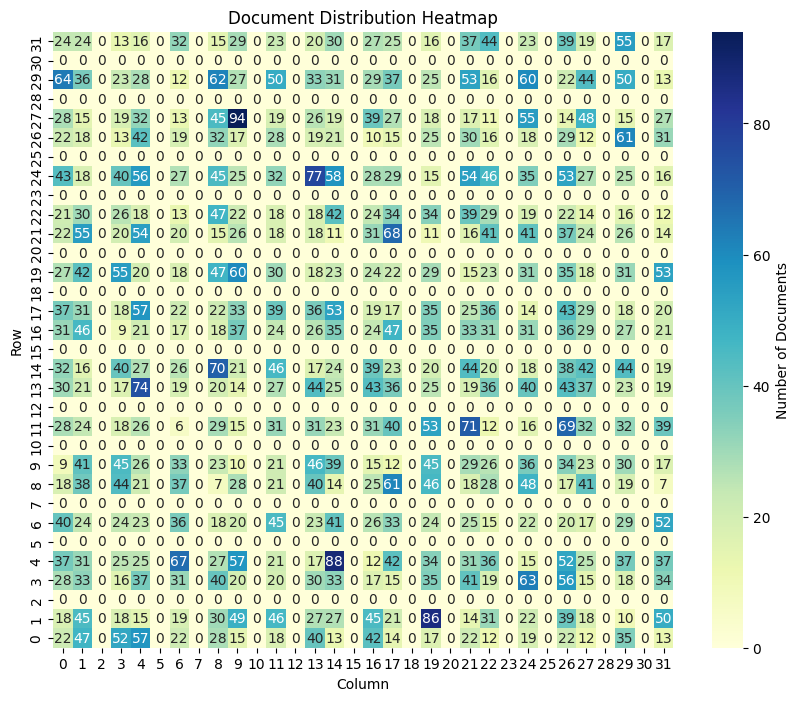

In [ ]:
import seaborn as sns
# Create a 16x16 grid
grid_size = 32
grid = np.zeros((grid_size, grid_size), dtype=int)
doc_vec = winning_nodes
# Map document_ids to grid coordinates
for i, (x, y) in enumerate(doc_vec):
    document_id = i + 1
    row = int((y - doc_vec[:, 1].min()) / (doc_vec[:, 1].max() - doc_vec[:, 1].min()) * (grid_size - 1))
    col = int((x - doc_vec[:, 0].min()) / (doc_vec[:, 0].max() - doc_vec[:, 0].min()) * (grid_size - 1))
    grid[row, col] += 1

# Create a heatmap using seaborn
plt.figure(figsize=(10, 8))
ax = sns.heatmap(grid, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={"label": "Number of Documents"})
plt.xlabel('Column')
plt.ylabel('Row')
plt.title('Document Distribution Heatmap')
ax.invert_yaxis()
plt.show()

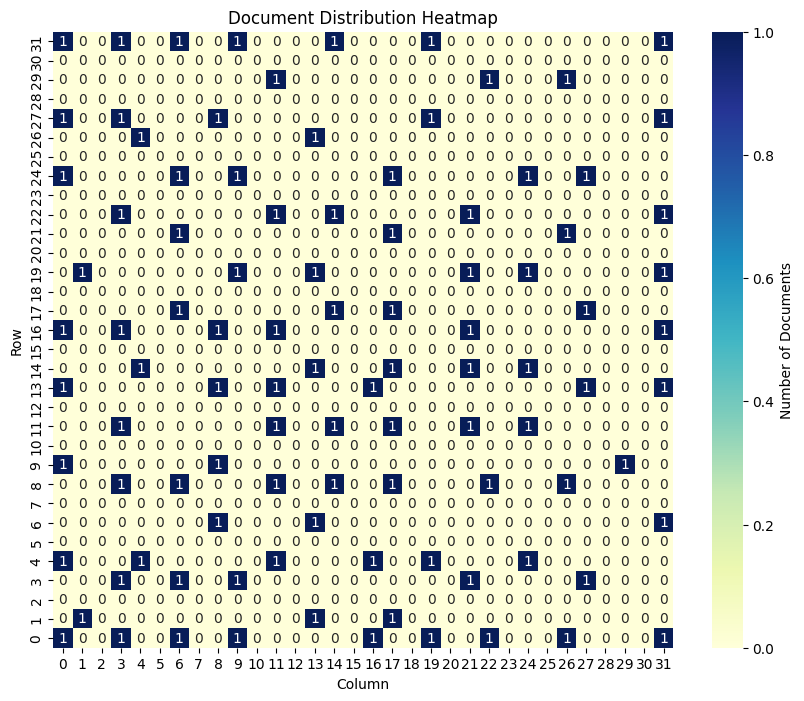

In [ ]:
import seaborn as sns
# Create a 16x16 grid
grid_size = 32
grid = np.zeros((grid_size, grid_size), dtype=int)
doc_vec = winning_nodes
# Map document_ids to grid coordinates
for i, (x, y) in enumerate(doc_vec):
    document_id = i + 1
    row = int((y - doc_vec[:, 1].min()) / (doc_vec[:, 1].max() - doc_vec[:, 1].min()) * (grid_size - 1))
    col = int((x - doc_vec[:, 0].min()) / (doc_vec[:, 0].max() - doc_vec[:, 0].min()) * (grid_size - 1))
    grid[row, col] += 1

# Create a heatmap using seaborn
plt.figure(figsize=(10, 8))
ax = sns.heatmap(grid, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={"label": "Number of Documents"})
plt.xlabel('Column')
plt.ylabel('Row')
plt.title('Document Distribution Heatmap')
ax.invert_yaxis()
plt.show()

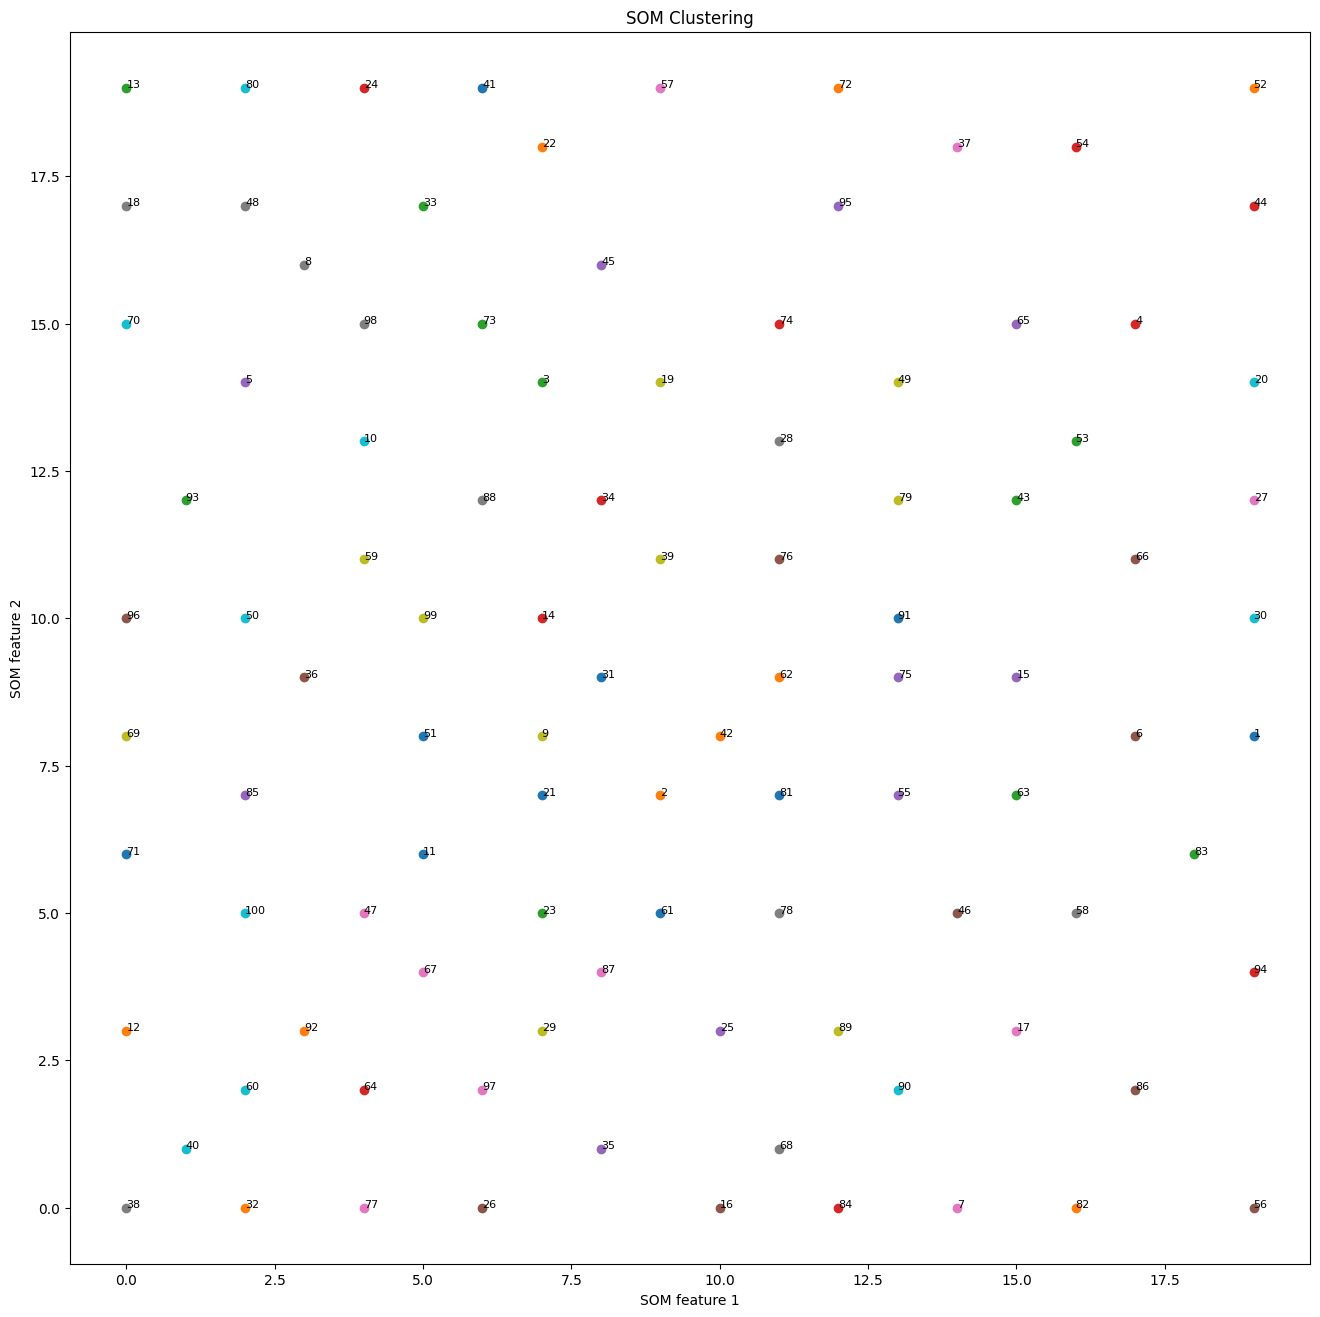

In [ ]:
# Plot SOM clusters
plt.figure(figsize=(16, 16))
for i, (x, y) in enumerate(doc_vec):
    document_id = i + 1
    plt.scatter(x, y)
    plt.annotate(str(document_id), (x, y), fontsize=8)  # Adjust the fontsize parameter
plt.xlabel('SOM feature 1')
plt.ylabel('SOM feature 2')
plt.title('SOM Clustering')
plt.show()

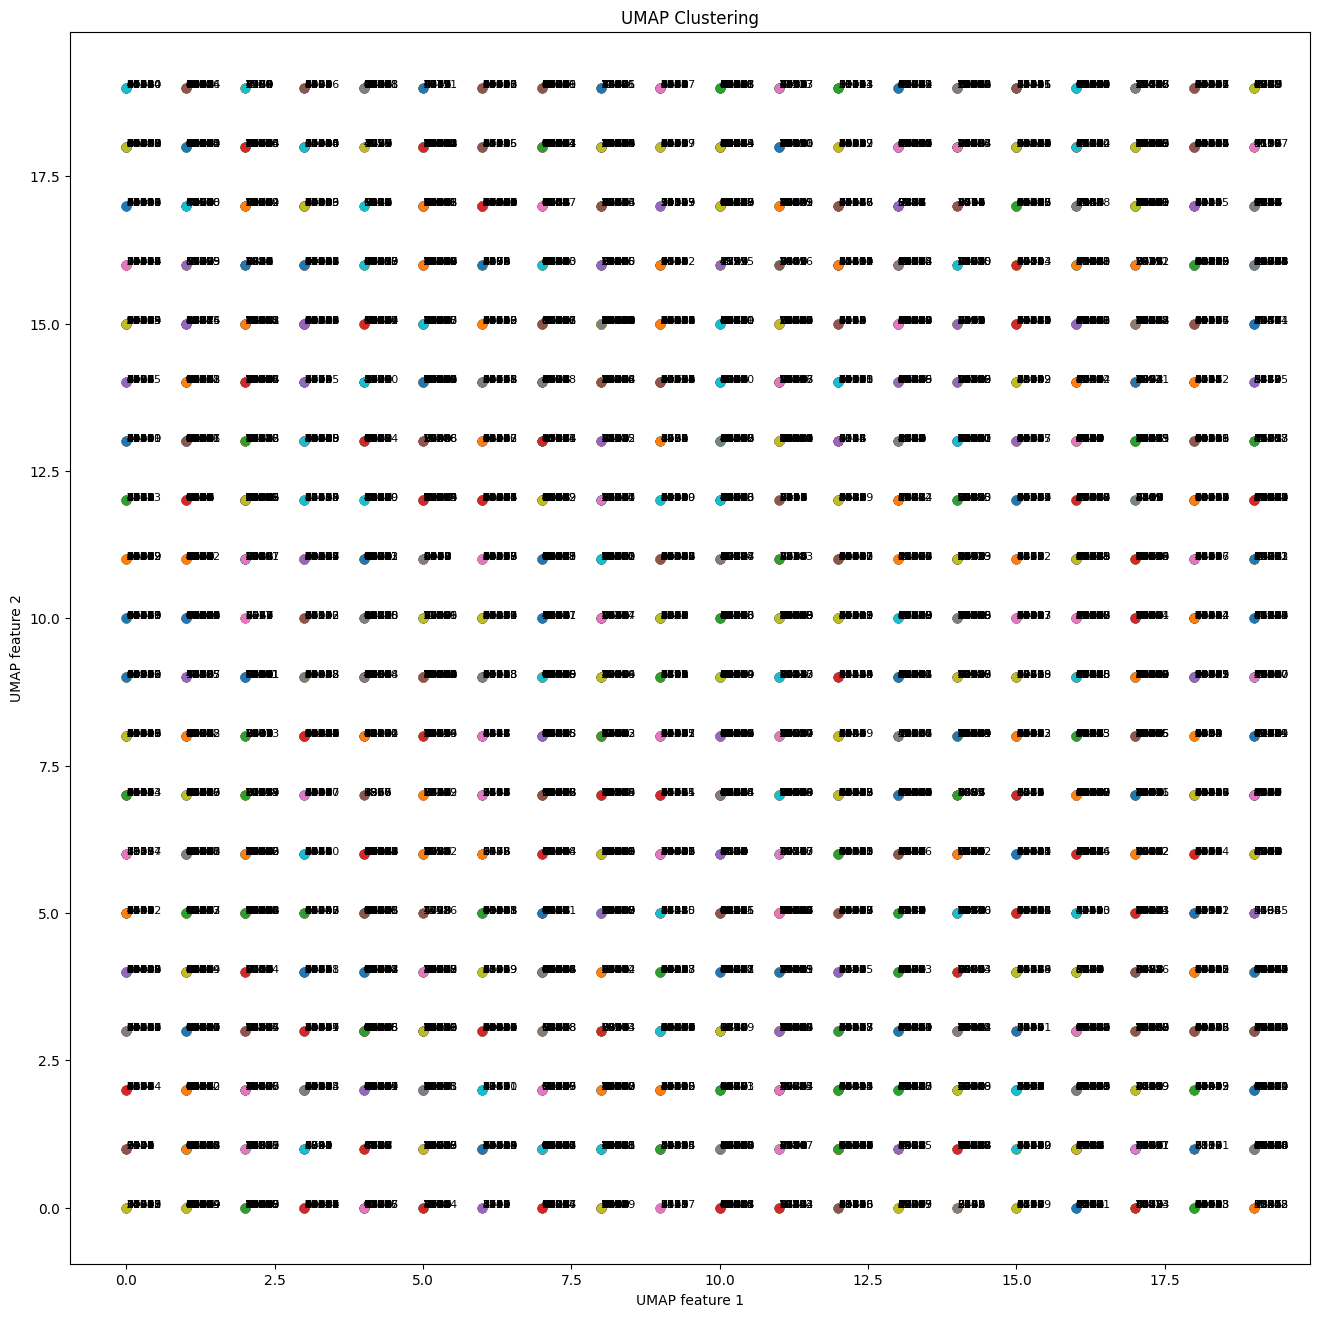

In [ ]:
# Plot SOM clusters
plt.figure(figsize=(16, 16))
for i, (x, y) in enumerate(doc_vec):
    document_id = i + 1
    plt.scatter(x, y)
    plt.annotate(str(document_id), (x, y), fontsize=8)  # Adjust the fontsize parameter
plt.xlabel('SOM feature 1')
plt.ylabel('SOM feature 2')
plt.title('SOM Clustering')
plt.show()

In [ ]:
import numpy as np

def calculate_euclidean_distance(vector1, vector2):
    return np.linalg.norm(vector1 - vector2)

# Get the number of document vectors
max_id = len(winning_nodes)
# Calculate all possible pairwise distances
distances = []
for i in range(max_id):
    for j in range(i + 1, max_id):  # Avoid redundant calculations
        vector1 = winning_nodes[i]
        vector2 = winning_nodes[j]
        dist = calculate_euclidean_distance(vector1, vector2)
        print(i+1, j+1, dist)


1 2 10.04987562112089
1 3 13.416407864998739
1 4 7.280109889280518
1 5 18.027756377319946
1 6 2.0
1 7 9.433981132056603
1 8 17.88854381999832
1 9 12.0
1 10 15.811388300841896
1 11 14.142135623730951
1 12 19.6468827043885
1 13 21.95449840010015
1 14 12.165525060596439
1 15 4.123105625617661
1 16 12.041594578792296
1 17 6.4031242374328485
1 18 21.02379604162864
1 19 11.661903789690601
1 20 6.0
1 21 12.041594578792296
1 22 15.620499351813308
1 23 12.36931687685298
1 24 18.601075237738275
1 25 10.295630140987
1 26 15.264337522473747
1 27 4.0
1 28 9.433981132056603
1 29 13.0
1 30 2.0
1 31 11.045361017187261
1 32 18.788294228055936
1 33 16.64331697709324
1 34 11.704699910719626
1 35 13.038404810405298
1 36 16.0312195418814
1 37 11.180339887498949
1 38 20.615528128088304
1 39 10.44030650891055
1 40 19.313207915827967
1 41 17.029386365926403
1 42 9.0
1 43 5.656854249492381
1 44 9.0
1 45 13.601470508735444
1 46 5.830951894845301
1 47 15.297058540778355
1 48 19.235384061671343
1 49 8.48528137423